# Logistic regression

In [30]:
# Import necessary packages
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import DecisionBoundaryDisplay

In [2]:
iris = load_iris()
X = iris.data[:, :4]
y = iris.target
type(X)

numpy.ndarray

Perform Logisitic Regression and kNN on this dataset following the below steps:

1.  Preprocess the data
    * Check for empty values or nulls and perform necessary imputations/deletions
    * Encode the class variable numerically using the label encoder
    * Scale features as necessary
2. Logistic regression
    * Create a logistic regression model
    * Fit the logistic regression model to the train data
    * Get predictions for the class variable (y)
    * Get the train accuracy and test accuracy. Here accuracy is basically the fraction of correctly classified samples, i.e., y_pred==y_true.
3. Plotting the decision boundaries for Logistic Regression
    * Create scatter plots taking any two features at a time
    * Plot the decision boundary using sklearn's DecisionBoundaryDisplay
4. kNN
    * Create a kNN model
    * Fit the kNN to the train data
    * Get predictions for the class variable (y)
    * Get the train accuracy and test accuracy. Here accuracy is basically the fraction of correctly classified samples, i.e., y_pred==y_true.
5. Plotting the decision boundaries for Logistic Regression
    * Create scatter plots taking any two features at a time
    * Plot the decision boundary using sklearn's DecisionBoundaryDisplay

In [37]:
# Preprocessing the data

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
# Logistic Regression

# Create a logistic regression model
logistic_model = LogisticRegression(max_iter=200, random_state=42)

# Fit the logistic regression model to the train data
logistic_model.fit(X_train_scaled, y_train)

# Get predictions for the class variable (y)
y_train_pred = logistic_model.predict(X_train_scaled)
y_test_pred = logistic_model.predict(X_test_scaled)

# Get the train accuracy and test accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Logistic Regression - Train Accuracy: {train_accuracy:.4f}")
print(f"Logistic Regression - Test Accuracy: {test_accuracy:.4f}")

Logistic Regression - Train Accuracy: 0.9619
Logistic Regression - Test Accuracy: 1.0000


In [44]:
print("Coefficients:", logistic_model.coef_)
print("Intercept:", logistic_model.intercept_)

Coefficients: [[-0.96229141  1.02709252 -1.74177531 -1.59749108]
 [ 0.48511907 -0.3432642  -0.30050696 -0.66873113]
 [ 0.47717234 -0.68382832  2.04228227  2.26622221]]
Intercept: [-0.60002573  1.83722745 -1.23720172]


In [ ]:
# Scatter plot

In [39]:
# Confusion Matrix
cnf_matrix = metrics.confusion_matrix(y_test, y_test_pred)
cnf_matrix

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

Text(0.5, 427.9555555555555, 'Predicted label')

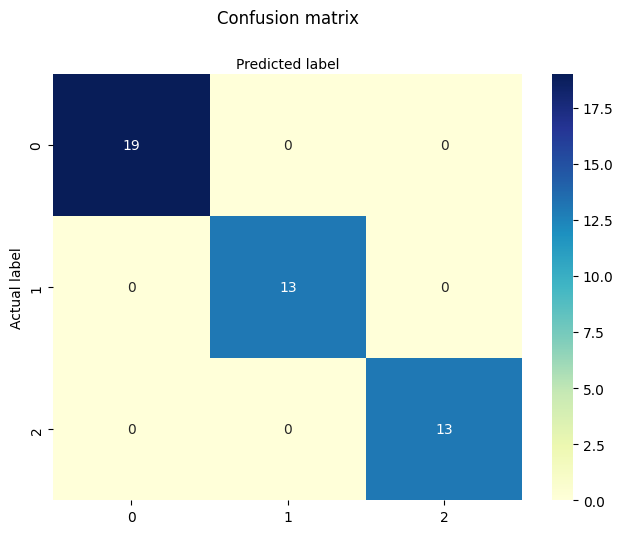

In [40]:
class_names=[0,1,2] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

# try changing the test split ratio and observe the differences in the matrix

In [28]:
# Classification Report

class_report = classification_report(y_test, y_test_pred, target_names=iris.target_names)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [ ]:
# kNN Model and Decision Boundary Visualization

# Create a kNN model (using n_neighbors=5 as a default, can be tuned)
knn_model_2d = KNeighborsClassifier(n_neighbors=5)

# Fit the kNN model to the scaled 2D training data
knn_model_2d.fit(X_2d_train_scaled, y_2d_train)

# Get predictions for the class variable (y) - for accuracy
y_train_pred_knn = knn_model_2d.predict(X_2d_train_scaled)
y_test_pred_knn = knn_model_2d.predict(X_2d_test_scaled)

# Get the train accuracy and test accuracy
train_accuracy_knn = accuracy_score(y_2d_train, y_train_pred_knn)
test_accuracy_knn = accuracy_score(y_2d_test, y_test_pred_knn)

print(f"kNN - Train Accuracy (2D): {train_accuracy_knn:.4f}")
print(f"kNN - Test Accuracy (2D): {test_accuracy_knn:.4f}")

# Create a figure and an axes object for the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Get feature names for axis labels
feature_names_2d = iris.feature_names[:2]

# Plot the decision boundary using DecisionBoundaryDisplay for kNN
disp_knn = DecisionBoundaryDisplay.from_estimator(
    knn_model_2d,
    X_2d_train_scaled,
    cmap=plt.cm.RdYlBu,
    alpha=0.6,
    ax=ax,
    xlabel=feature_names_2d[0],
    ylabel=feature_names_2d[1]
)

# Plot the training points (scatter plot)
scatter_knn = ax.scatter(X_2d_train_scaled[:, 0], X_2d_train_scaled[:, 1],
                         c=y_2d_train, cmap=plt.cm.RdYlBu,
                         edgecolor='k', s=20)

# Add a legend for the classes
handles_knn, labels_knn = scatter_knn.legend_elements(num=[0, 1, 2])
ax.legend(handles=handles_knn, labels=iris.target_names, title="Classes")

ax.set_title("kNN Decision Boundary (Sepal Length vs Sepal Width)")
plt.show()

In [52]:
# Decision Boundary
# Add polynomial features and visualize the decision boundary

# Parameter values
a0 = log_reg.intercept_[0]
a1 = log_reg.coef_[0][0]
a2 = log_reg.coef_[0][1]



array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
pipeline = Pipeline([
    (Minmax Scaler)
    (Polyfeatures(degree=2))
    (LogisticRegression)])
pipeline.fit(X_train)
y_test_pred = pipeline.predict(X_test)